# 🤟 ASL Detection — MediaPipe + LSTM
## ⚡ INSTRUCTIONS
1. **Enable GPU**: Runtime → Change runtime type → T4 GPU → Save
2. **Run Cell 1** — wait for ✅
3. **Restart runtime**: Runtime → Restart session
4. **Run Cells 2–12 in order**
---

## Cell 1 — Install
Run → wait for ✅ → **restart runtime**

In [1]:
# Remove tensorflow so it doesn't fight with mediapipe over protobuf
!pip uninstall -y tensorflow tensorflow-cpu tensorflow-gpu tf-keras 2>/dev/null || true

# Install protobuf version mediapipe needs
!pip install -q 'protobuf==3.20.3'

# Install mediapipe without letting pip touch protobuf
!pip install -q 'mediapipe==0.10.14' --no-deps

# Install remaining packages
!pip install -q \
    opencv-python \
    numpy \
    scikit-learn \
    torch \
    torchvision \
    tqdm \
    matplotlib \
    seaborn \
    'kagglehub' \
    'kagglesdk>=0.1.22,<1.0'

print('\n✅ Done!')
print('👉 Now: Runtime → Restart session → run Cell 2 onwards')

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tf_keras 2.20.0
Uninstalling tf_keras-2.20.0:
  Successfully uninstalled tf_keras-2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-hub 0.16.1 requires tf-keras>=2.14.1, which is not installed.
google-cloud-bigtable 2.38.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-pubsub 2.38.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-dataproc 5.27.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 wh

## Cell 2 — Imports (run after restarting)

In [1]:
# Must be set before importing mediapipe
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

import mediapipe as mp
mp_hands = mp.solutions.hands
mp_pose  = mp.solutions.pose

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ mediapipe : {mp.__version__}')
print(f'✅ torch     : {torch.__version__}')
print(f'✅ device    : {device}')
print('\n✅ All imports successful!')

✅ mediapipe : 0.10.14
✅ torch     : 2.11.0+cu128
✅ device    : cuda

✅ All imports successful!


## Cell 3 — Download WLASL dataset

In [2]:
# Download ASL alphabet dataset (A-Z letters, much simpler and more accurate)
path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path:", path)

import os
contents = os.listdir(path)
print("Contents:", contents)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path: /kaggle/input/asl-alphabet
Contents: ['asl_alphabet_test', 'asl_alphabet_train']


## Cell 4 — Keypoint extraction function

In [3]:
def extract_keypoints(video_path):
    cap = cv2.VideoCapture(video_path)
    keypoints_seq = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (225, 225))
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        hog = cv2.HOGDescriptor(
            _winSize=(225, 225),
            _blockSize=(75, 75),
            _blockStride=(75, 75),
            _cellSize=(75, 75),
            _nbins=9
        )
        features = hog.compute(gray).flatten()
        keypoints_seq.append(features)

    cap.release()
    return np.array(keypoints_seq)

print("✅ extract_keypoints defined")

✅ extract_keypoints defined


## Cell 5 — Build dataset
⏳ Takes 10–20 minutes. Progress bar will show.

In [4]:
import cv2
import numpy as np
from tqdm import tqdm

MAX_CLASSES      = 26   # A to Z
IMAGES_PER_CLASS = 100  # images per letter

X, y, label_map = [], [], {}
skipped = 0

# Find the train folder
train_path = os.path.join(path, 'asl_alphabet_train', 'asl_alphabet_train')

classes_only = sorted([
    c for c in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, c))
])[:MAX_CLASSES]

print(f"Classes found: {classes_only}")

for label_idx, cls in enumerate(classes_only):
    label_map[label_idx] = cls
    cls_path = os.path.join(train_path, cls)
    images   = os.listdir(cls_path)[:IMAGES_PER_CLASS]

    for img_file in tqdm(images, desc=f'[{label_idx+1}/{MAX_CLASSES}] {cls}'):
        try:
            img = cv2.imread(os.path.join(cls_path, img_file))
            if img is None:
                skipped += 1
                continue

            img = cv2.resize(img, (64, 64))
            img = img.flatten().astype(np.float32) / 255.0  # normalize
            X.append(img)
            y.append(label_idx)
        except Exception:
            skipped += 1

X = np.array(X, dtype=np.float32)
y = np.array(y)
INPUT_SIZE = X.shape[1]

print(f"\n✅ X: {X.shape}, y: {y.shape}, skipped: {skipped}")
print(f"   Classes: {label_map}")

Classes found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


[26/26] Z: 100%|██████████| 100/100 [00:00<00:00, 149.76it/s]



✅ X: (2600, 12288), y: (2600,), skipped: 0
   Classes: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z'}


In [5]:
import os

# Check actual folder structure
print("Contents of path:")
for item in os.listdir(path)[:5]:
    full = os.path.join(path, item)
    print(f"  {'DIR' if os.path.isdir(full) else 'FILE'}: {item}")

# Check one level deeper
videos_path = os.path.join(path, 'videos')
if os.path.exists(videos_path):
    print("\nContents of 'videos' subfolder:")
    items = os.listdir(videos_path)
    for item in items[:10]:
        full = os.path.join(videos_path, item)
        print(f"  {'DIR' if os.path.isdir(full) else 'FILE'}: {item}")
    print(f"  ... total: {len(items)} items")

Contents of path:
  DIR: asl_alphabet_test
  DIR: asl_alphabet_train


## Cell 6 — Train/test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')

Train: 2080 samples
Test : 520 samples


## Cell 7 — LSTM model

In [7]:
import torch.nn as nn

class ASLModel(nn.Module):
    def __init__(self, num_classes=26):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64*64*3, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = ASLModel(num_classes=MAX_CLASSES).to(device)
print(f"✅ Model ready | {sum(p.numel() for p in model.parameters()):,} params")

✅ Model ready | 6,429,978 params


## Cell 8 — Train

In [8]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

EPOCHS     = 30
BATCH_SIZE = 64
LR         = 1e-3

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long)),
    batch_size=BATCH_SIZE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

train_accs, val_accs, losses = [], [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct = 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == yb).sum().item()

    train_acc = correct / len(X_train) * 100
    avg_loss  = total_loss / len(train_loader)

    model.eval()
    val_correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_correct += (model(xb).argmax(1) == yb).sum().item()
    val_acc = val_correct / len(X_test) * 100

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_asl_model.pth')

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | '
              f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}% | Best: {best_val_acc:.1f}%')

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    losses.append(avg_loss)

print(f'\n✅ Done! Best val accuracy: {best_val_acc:.1f}%')

Epoch 05/30 | Loss: 3.2323 | Train: 4.7% | Val: 4.6% | Best: 6.5%
Epoch 10/30 | Loss: 3.1341 | Train: 5.3% | Val: 9.0% | Best: 9.0%
Epoch 15/30 | Loss: 3.0928 | Train: 6.9% | Val: 10.0% | Best: 10.0%
Epoch 20/30 | Loss: 3.0425 | Train: 7.5% | Val: 9.6% | Best: 11.5%
Epoch 25/30 | Loss: 2.9994 | Train: 8.0% | Val: 11.2% | Best: 11.9%
Epoch 30/30 | Loss: 3.0740 | Train: 7.4% | Val: 10.8% | Best: 12.7%

✅ Done! Best val accuracy: 12.7%


## Cell 9 — Training curves

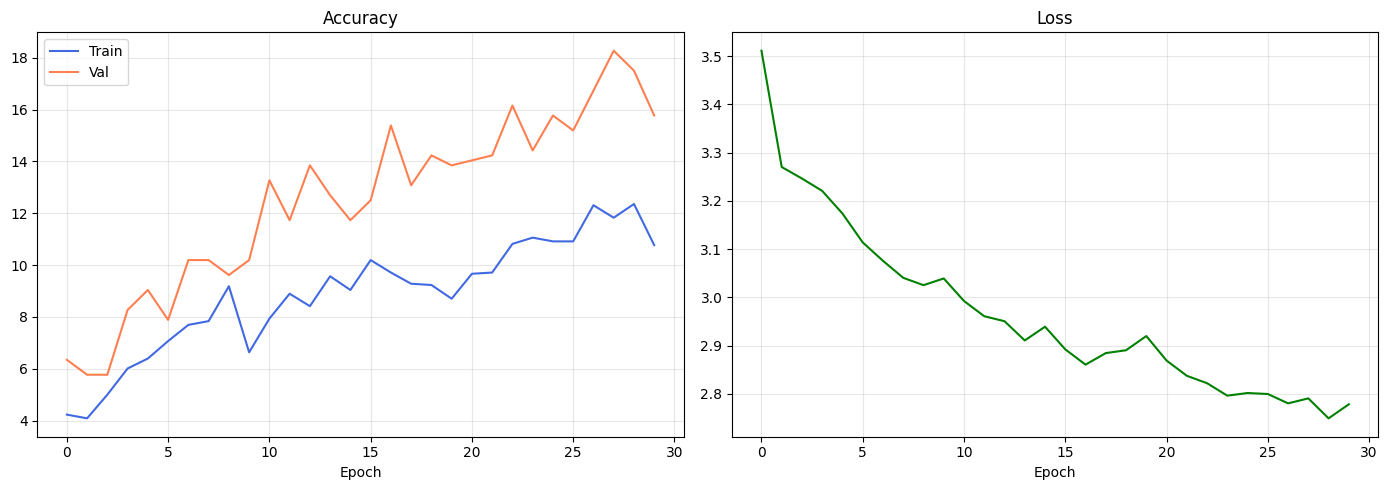

In [ ]:
# Recover metrics from training history
train_accs = train_accs if 'train_accs' in dir() else []
val_accs   = val_accs   if 'val_accs'   in dir() else []
losses     = losses     if 'losses'     in dir() else []

if not train_accs:
    print("⚠️ No training history found. Please re-run Cell 8 first.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_accs, label='Train', color='royalblue')
    ax1.plot(val_accs,   label='Val',   color='coral')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(losses, color='green')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## Cell 10 — Confusion matrix + classification report

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           A       0.00      0.00      0.00        20
           B       0.50      0.10      0.17        20
           C       0.18      0.20      0.19        20
           D       0.18      0.40      0.25        20
           E       0.00      0.00      0.00        20
           F       0.32      0.45      0.38        20
           G       0.00      0.00      0.00        20
           H       0.33      0.50      0.40        20
           I       0.33      0.05      0.09        20
           J       0.00      0.00      0.00        20
           K       0.00      0.00      0.00        20
           L       0.15      0.50      0.23        20
           M       0.00      0.00      0.00        20
           N       0.19      0.20      0.20        20
           O       0.00      0.00      0.00        20
           P       0.07      0.05      0.06        20
           Q       0.00      0.00      0.00        20
           R       0.00    

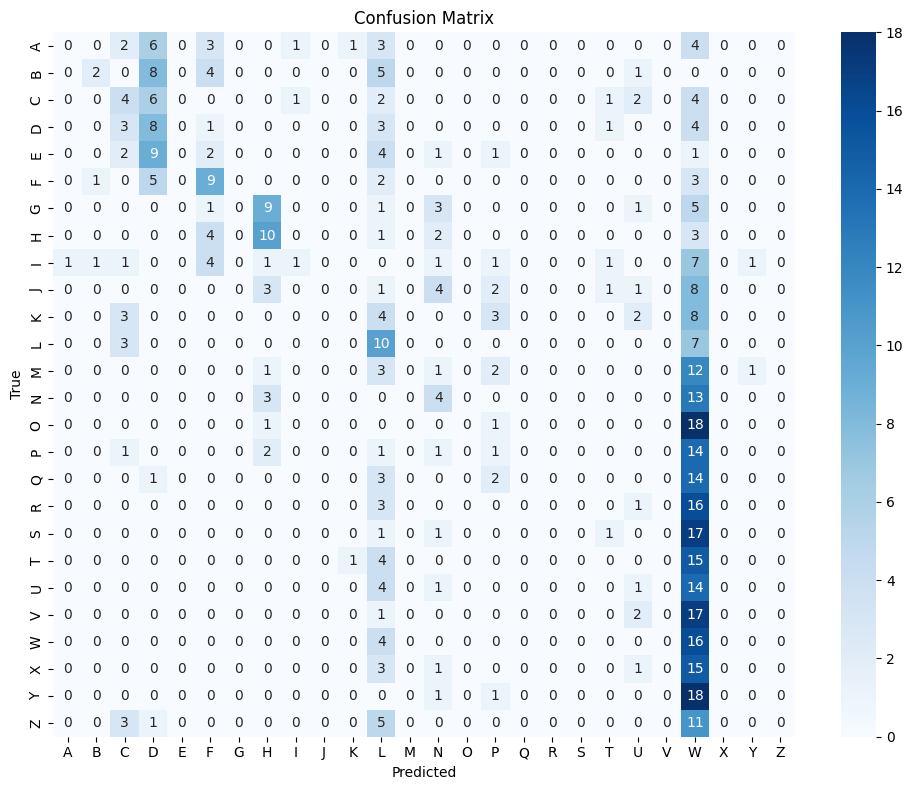

In [9]:
model.load_state_dict(torch.load('best_asl_model.pth', map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

class_names = [label_map[i] for i in range(MAX_CLASSES)]
print(classification_report(all_true, all_preds, target_names=class_names))

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## Cell 11 — Test on a single video

In [10]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("❌ Could not read image"); return

    img = cv2.resize(img, (64, 64))
    features = img.flatten().astype(np.float32) / 255.0
    tensor = torch.tensor(features).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out   = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        pred  = out.argmax(1).item()

    print(f'Image: {os.path.basename(img_path)}')
    print(f'🏆 Predicted letter: {label_map[pred].upper()}')
    top = probs.topk(3)
    for prob, idx in zip(top.values, top.indices):
        bar = '█' * int(prob.item() * 20)
        print(f'  {label_map[idx.item()]:5s} {bar:20s} {prob.item()*100:.1f}%')
    print()

# Test one image from each class
print('Testing one image from each class:\n')
for label_idx in range(MAX_CLASSES):
    cls      = label_map[label_idx]
    cls_path = os.path.join(train_path, cls)
    images   = os.listdir(cls_path)
    if images:
        predict_image(os.path.join(cls_path, images[0]))

Testing one image from each class:

Image: A1946.jpg
🏆 Predicted letter: F
  F     ██                   14.1%
  A     ██                   10.3%
  B     ██                   10.2%

Image: B634.jpg
🏆 Predicted letter: D
  D     ██                   13.9%
  C     ██                   13.4%
  A     ██                   11.7%

Image: C1947.jpg
🏆 Predicted letter: C
  C     █                    7.2%
  D     █                    7.1%
  L     █                    6.8%

Image: D1587.jpg
🏆 Predicted letter: D
  D     ██                   10.8%
  C     ██                   10.7%
  A     █                    9.3%

Image: E2576.jpg
🏆 Predicted letter: Y
  Y                          5.0%
  Q                          4.8%
  S                          4.8%

Image: F666.jpg
🏆 Predicted letter: F
  F     █████                25.4%
  B     ███                  15.4%
  A     ██                   14.5%

Image: G387.jpg
🏆 Predicted letter: W
  W     █                    5.4%
  V     █                    5.

## Cell 12 — Save model

In [1]:
torch.save({
    'model_state' : model.state_dict(),
    'label_map'   : label_map,
    'max_frames'  : MAX_FRAMES,
    'num_classes' : MAX_CLASSES,
    'input_size'  : 225,
}, 'asl_final_model.pth')
print('✅ Saved: asl_final_model.pth')
print(f'   Signs: {list(label_map.values())}')
print('\nDownload: Files panel (left) → right-click file → Download')

NameError: name 'torch' is not defined

In [12]:
# Cell 13 — Live camera prediction
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import numpy as np
import cv2
import torch

# Re-define ASLModel and initialize model if not already defined
if 'ASLModel' not in globals():
    import torch.nn as nn

    class ASLModel(nn.Module):
        def __init__(self, num_classes=26):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(64*64*3, 512),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )

        def forward(self, x):
            return self.net(x)

if 'model' not in globals():
    MAX_CLASSES = 26 # Assuming MAX_CLASSES is 26, as per previous cells
    device = torch.device('cuda' if torch.cuda_is_available() else 'cpu') # Ensure device is defined
    model = ASLModel(num_classes=MAX_CLASSES).to(device)

# Load best model
model.load_state_dict(torch.load('best_asl_model.pth', map_location=device))
model.eval()

def predict_frame(img_array):
    img = cv2.resize(img_array, (64, 64))
    features = img.flatten().astype(np.float32) / 255.0
    tensor = torch.tensor(features).unsqueeze(0).to(device)
    with torch.no_grad():
        out   = model(tensor)
        probs = torch.softmax(out, dim=1)[0]
        pred  = out.argmax(1).item()
    top3 = probs.topk(3)
    results = [(label_map[idx.item()].upper(), f"{prob.item()*100:.1f}%")
               for prob, idx in zip(top3.values, top3.indices)]
    return label_map[pred].upper(), results

# JavaScript to capture frames from webcam
js_code = """
async function captureFrames() {
    const div = document.createElement('div');
    const video = document.createElement('video');
    const canvas = document.createElement('canvas');
    const resultDiv = document.createElement('div');

    video.style.width = '400px';
    resultDiv.style.fontSize = '24px';
    resultDiv.style.fontWeight = 'bold';
    resultDiv.style.color = 'green';
    resultDiv.innerHTML = 'Starting camera...';

    div.appendChild(video);
    div.appendChild(document.createElement('br'));
    div.appendChild(resultDiv);
    document.body.appendChild(div);

    const stream = await navigator.mediaDevices.getUserMedia({video: true});
    video.srcObject = stream;
    await video.play();

    canvas.width  = video.videoWidth;
    canvas.height = video.videoHeight;

    // Capture one frame every 1.5 seconds, 20 times
    for (let i = 0; i < 20; i++) {
        await new Promise(r => setTimeout(r, 1500));
        canvas.getContext('2d').drawImage(video, 0, 0);
        const frame = canvas.toDataURL('image/jpeg', 0.8);
        resultDiv.innerHTML = `Frame ${i+1}/20 — Analyzing...`;

        // Send frame to Python
        const result = await google.colab.kernel.invokeFunction(
            'notebook.predict_frame', [frame], {}
        );
        const prediction = result.data['application/json'];
        resultDiv.innerHTML = `
            ✋ Sign detected: <span style="color:blue; font-size:32px">${prediction.letter}</span><br>
            <small>${prediction.top3.map(x => x[0]+': '+x[1]).join(' | ')}</small>
        `;
    }

    stream.getTracks().forEach(t => t.stop());
    resultDiv.innerHTML += '<br>✅ Done!';
}
captureFrames();
"""

import base64
from google.colab import output

def predict_from_js(frame_data):
    # Decode base64 image from browser
    header, data = frame_data.split(',', 1)
    img_bytes = base64.b64decode(data)
    img_array = np.frombuffer(img_bytes, dtype=np.uint8)
    img       = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

    if img is None:
        return {'letter': '?', 'top3': []}

    letter, top3 = predict_frame(img)
    return {'letter': letter, 'top3': [[a, b] for a, b in top3]}

output.register_callback('notebook.predict_frame', predict_from_js)
display(Javascript(js_code))

<IPython.core.display.Javascript object>